In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

import random
import cv2
import sys
import gc
import os
import time
import warnings

from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.autograd import Variable, detect_anomaly
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid

from PIL import Image, ImageOps, ImageEnhance

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
train_size = len(os.listdir("../data/train/"))
test_size = len(os.listdir("../data/test/"))
print(f"学習データの枚数: {train_size}")
print(f"テストデータの枚数: {test_size}")

学習データの枚数: 60000
テストデータの枚数: 10000


In [6]:
seeds = 777
torch.manual_seed(seeds)
random.seed(seeds)
np.random.seed(seeds)
torch.cuda.manual_seed(seeds)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

# 適当な画像を確認

In [7]:
image = Image.open(os.path.join('../data/train', 'train_0.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


In [8]:
image = Image.open(os.path.join('../data/train', 'train_12.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


In [9]:
image = Image.open(os.path.join('../data/test', 'test_0.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


それぞれ画像の大きさは横×縦が28×28で, グレースケール画像であることが確認できました.

学習用画像データにおけるそれぞれの数字の分布をみてみます.

In [10]:
train_master = pd.read_csv("../assets/train_master.csv")
train_master.head()

,file_name,category_id
0,train_0.jpg,5
1,train_1.jpg,0
2,train_2.jpg,4
3,train_3.jpg,1
4,train_4.jpg,9


In [11]:
train_master['category_id'].value_counts().sort_index()

category_id
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

# 手法
次に実際にモデリングを行い, 評価用画像データに対して予測をできるようにします.

今回はLeNetの畳み込みステムを活用し、Capsule Network (CapsNet) によりモデリングを試みます.

実装はpytorchを用います.

まず60,000枚の学習用画像データを読み込みます. その際, あらかじめデータの数値の範囲が[0, 1]となるように正規化しておきます.

pytorchではモデルに学習データを渡す際は(サンプル数, チャンネル数, 縦, 横)の形でなければならないので, そのように変形しておきます.

# DataLoader

In [12]:
class MNIST_data(Dataset):
    """MNIST dtaa set"""

    def __init__(self, data, mode, transform=None):

        self.df = data
        self.tsfm = transform
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name, label = self.df.loc[idx, "file_name"], self.df.loc[idx, "category_id"]
        if self.mode == "train":
            image = cv2.imread(f"../data/{self.mode}/{image_name}", cv2.IMREAD_GRAYSCALE)
            label = torch.tensor(label)
            if self.tsfm != None:
                image = self.tsfm(image.astype(dtype=np.uint8))
            else:
                image = torch.FloatTensor(image)

        else:
            image = cv2.imread(f"../data/{self.mode}/{image_name}", cv2.IMREAD_GRAYSCALE)
            label = torch.tensor(label)
            if self.tsfm != None:
                image = self.tsfm(image.astype(dtype=np.uint8))
            else:
                image = torch.FloatTensor(image)

        return image, label

In [13]:
transform_train = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize([0.5], [0.5])])
transform_test = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize([0.5], [0.5])])

In [14]:
sample = MNIST_data(train_master, mode="train", transform=transform_train)
sample_loader = torch.utils.data.DataLoader(dataset=sample, batch_size=16, shuffle=True, worker_init_fn=seeds)

確認

In [15]:
images, labels = next(iter(sample_loader))

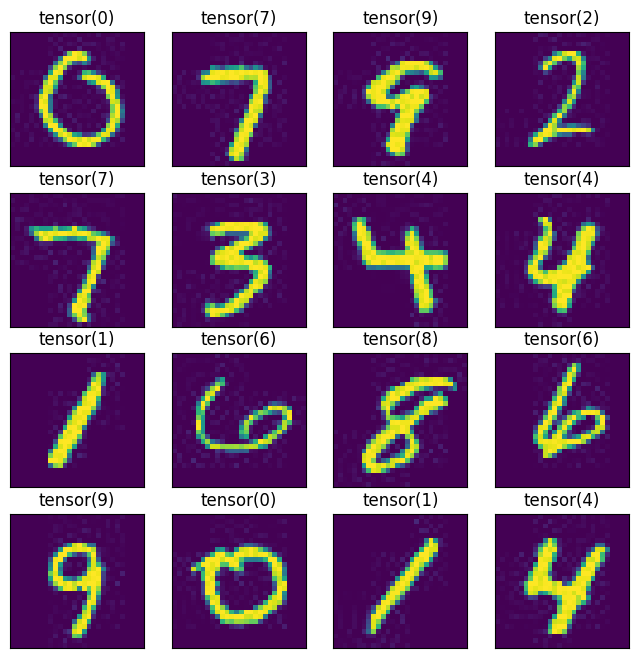

In [16]:
plt.figure(figsize=(8,8))
for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4,i+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(label)
    plt.xticks(())
    plt.yticks(())
plt.show()

# Model作成&損失関数設定

In [17]:
class LeNet(nn.Module):
    def __init__(self, output_size=10, activation='relu'):
        super(LeNet, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, output_size)

        # 活性化関数の辞書
        self.activations = {
            'relu': F.relu,
            'sigmoid': torch.sigmoid,
            'tanh': torch.tanh
        }

    def forward(self, x):
        act_func = self.activations.get(self.activation, F.relu)
        x = self.pool(act_func(self.conv1(x)))
        x = self.pool(act_func(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = act_func(self.fc1(x))
        x = act_func(self.fc2(x))
        x = self.fc3(x)
        return x


# 変更開始: Capsule Network の実装
def squash(tensor, dim=-1):
    """
    カプセルのスカッシュ関数
    ベクトルの長さを0-1の範囲に正規化する
    """
    squared_norm = (tensor ** 2).sum(dim=dim, keepdim=True)
    scale = squared_norm / (1 + squared_norm)
    return scale * tensor / torch.sqrt(squared_norm + 1e-8)


class PrimaryCaps(nn.Module):
    """
    Primary Capsule Layer
    畳み込み層の出力をカプセル表現に変換
    """
    def __init__(self, in_channels, out_channels, dim_caps, kernel_size, stride=1, padding=0):
        super(PrimaryCaps, self).__init__()
        self.dim_caps = dim_caps
        self.conv = nn.Conv2d(in_channels, out_channels * dim_caps, 
                             kernel_size=kernel_size, stride=stride, padding=padding)
    
    def forward(self, x):
        # x: [batch_size, in_channels, H, W]
        out = self.conv(x)  # [batch_size, out_channels*dim_caps, H', W']
        batch_size = out.size(0)
        
        # カプセル形状に変換: [batch_size, num_caps, dim_caps]
        out = out.view(batch_size, -1, self.dim_caps)
        
        # スカッシュ関数を適用
        return squash(out)


class DigitCaps(nn.Module):
    """
    Digit Capsule Layer (Dynamic Routing)
    各クラスに対応するカプセルを生成
    """
    def __init__(self, in_num_caps, in_dim_caps, out_num_caps, out_dim_caps, num_routing=3):
        super(DigitCaps, self).__init__()
        self.in_num_caps = in_num_caps
        self.in_dim_caps = in_dim_caps
        self.out_num_caps = out_num_caps
        self.out_dim_caps = out_dim_caps
        self.num_routing = num_routing
        
        # 変換行列: [1, in_num_caps, out_num_caps, out_dim_caps, in_dim_caps]
        self.W = nn.Parameter(torch.randn(1, in_num_caps, out_num_caps, out_dim_caps, in_dim_caps))
    
    def forward(self, x):
        # x: [batch_size, in_num_caps, in_dim_caps]
        batch_size = x.size(0)
        
        # x を拡張: [batch_size, in_num_caps, 1, in_dim_caps, 1]
        x = x.unsqueeze(2).unsqueeze(4)
        
        # W を拡張: [batch_size, in_num_caps, out_num_caps, out_dim_caps, in_dim_caps]
        W = self.W.repeat(batch_size, 1, 1, 1, 1)
        
        # u_hat = W @ x: [batch_size, in_num_caps, out_num_caps, out_dim_caps, 1]
        u_hat = torch.matmul(W, x)
        u_hat = u_hat.squeeze(4)  # [batch_size, in_num_caps, out_num_caps, out_dim_caps]
        
        # Dynamic Routing
        b = torch.zeros(batch_size, self.in_num_caps, self.out_num_caps, 1).to(x.device)
        
        for iteration in range(self.num_routing):
            # Softmax over out_num_caps dimension
            c = F.softmax(b, dim=2)  # [batch_size, in_num_caps, out_num_caps, 1]
            
            # s = sum(c * u_hat): [batch_size, out_num_caps, out_dim_caps]
            s = (c * u_hat).sum(dim=1)
            
            # v = squash(s): [batch_size, out_num_caps, out_dim_caps]
            v = squash(s, dim=-1)
            
            # 最後のiterationでは b を更新しない
            if iteration < self.num_routing - 1:
                # b を更新: [batch_size, in_num_caps, out_num_caps, 1]
                v_expanded = v.unsqueeze(1)  # [batch_size, 1, out_num_caps, out_dim_caps]
                agreement = (u_hat * v_expanded).sum(dim=-1, keepdim=True)
                b = b + agreement
        
        return v  # [batch_size, out_num_caps, out_dim_caps]


class CapsNet(nn.Module):
    """
    Capsule Network
    LeNetの畳み込みステムを再利用し、CapsuleレイヤーでMNIST分類を行う
    """
    def __init__(self, output_size=10, activation='relu'):
        super(CapsNet, self).__init__()
        self.activation = activation
        
        # LeNetの畳み込みステムを再利用
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        
        # 活性化関数の辞書
        self.activations = {
            'relu': F.relu,
            'sigmoid': torch.sigmoid,
            'tanh': torch.tanh
        }
        
        # Primary Capsule Layer
        # 入力: 16チャンネル, 4x4の特徴マップ
        # 出力: 32個のカプセル, 各カプセルは8次元
        self.primary_caps = PrimaryCaps(in_channels=16, out_channels=32, 
                                       dim_caps=8, kernel_size=3, stride=1, padding=0)
        
        # Digit Capsule Layer (Dynamic Routing)
        # Primary Capsの出力サイズを計算: (4-3+0)/1+1 = 2
        # -> 32 * 2 * 2 = 128個のカプセル
        self.digit_caps = DigitCaps(in_num_caps=128, in_dim_caps=8,
                                    out_num_caps=output_size, out_dim_caps=16,
                                    num_routing=3)
    
    def forward(self, x):
        # LeNetの畳み込みステムを通す
        act_func = self.activations.get(self.activation, F.relu)
        x = self.pool(act_func(self.conv1(x)))  # [batch, 6, 12, 12]
        x = self.pool(act_func(self.conv2(x)))  # [batch, 16, 4, 4]
        
        # Primary Capsule Layer
        x = self.primary_caps(x)  # [batch, 128, 8]
        
        # Digit Capsule Layer
        x = self.digit_caps(x)  # [batch, 10, 16]
        
        # カプセルの長さを計算(クラススコア)
        x = torch.sqrt((x ** 2).sum(dim=-1))  # [batch, 10]
        
        return x
# 変更ここまで

In [18]:
# 変更開始: CapsNetモデルを使用
model = CapsNet(output_size=10, activation='relu')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# 変更ここまで

# 訓練

In [19]:
#GPUを使うか使わないか(使う場合cudaになり、使わない場合cpuとなる)
device = ""

if torch.cuda.is_available():
    device = "cuda"

if torch.backends.mps.is_available():
    device = "mps"

if device == "":
    device = "cpu"

In [20]:
model = model.to(device)

In [21]:
train, valid, _, _ = train_test_split(train_master, train_master["category_id"], test_size=0.25, random_state=seeds)
train = train.reset_index(drop=True)
valid = valid.reset_index(drop=True)

In [22]:
batch_size = 64
train_data = MNIST_data(train, mode="train", transform=transform_train)
valid_data = MNIST_data(valid, mode="train", transform=transform_test)
train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, worker_init_fn=seeds)
valid_loader = torch.utils.data.DataLoader(dataset=valid_data, batch_size=batch_size)

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [41]:
EPOCH = 40
total_batch = int(len(train_loader)/12)

In [42]:
# 学習→検証までの関数
def training_validation(input_model, EPOCH, training_data, validation_data, num_update):
    total_batch = int(len(training_data)/num_update)
    
    # 履歴を記録するリスト
    history = {
        'train_loss': [],
        'valid_loss': [],
        'valid_accuracy': []
    }
    
    for epoch in range(1, EPOCH+1):
        input_model.train()
        #訓練プロセス
        train_loss = []
        pbar = tqdm.tqdm(enumerate(training_data), total = len(training_data))
        for process, (images, labels) in pbar:
            images = images.to(device)
            labels = labels.to(device)
            time_1 = time.time()
            outputs = input_model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss = loss.item()
            train_loss.append(loss)
            if (process % total_batch == 0) | (process == len(training_data)):
                pbar.set_postfix(EPOCH=epoch, train_loss=np.mean(train_loss))

        #検証プロセス
        input_model.eval()
        valid_loss = []
        correct = 0
        valid_time = time.time()
        for process, (images, labels) in enumerate(validation_data):
            images = images.to(device)
            labels = labels.to(device)
            outputs = input_model(images)
            loss = criterion(outputs, labels)
            loss = loss.item()
            valid_loss.append(loss)
            pred = outputs.data.max(1, keepdim=True)[1]
            correct += pred.eq(labels.data.view_as(pred)).cpu().sum().item()
        minute, second = int((time.time()-valid_time)//59), int((time.time()-valid_time)%60)
        
        # エポックごとの結果を記録
        epoch_train_loss = np.mean(train_loss)
        epoch_valid_loss = np.mean(valid_loss)
        epoch_valid_accuracy = correct/len(validation_data.dataset)
        
        history['train_loss'].append(epoch_train_loss)
        history['valid_loss'].append(epoch_valid_loss)
        history['valid_accuracy'].append(epoch_valid_accuracy)
        
        pbar.set_postfix(EPOCH=epoch, train_loss=epoch_train_loss, valid_loss=epoch_valid_loss, valid_accuracy=epoch_valid_accuracy)
        print(f"valid_loss: {epoch_valid_loss}, valid_accuracy: {epoch_valid_accuracy}")

    return_model = input_model

    return return_model, history

In [43]:
# 予測結果のそれぞれの誤差の大きさを確認
def predict_img(input_model, input_data):
    input_model.eval()
    test_pred = torch.LongTensor()
    test_proba = torch.FloatTensor()
    for images, labels in tqdm.tqdm(input_data):
        images = images.to(device)
        labels = labels.to(device)
        outputs = input_model(images)
        pred_proba = F.softmax(outputs, dim=1).cpu()
        pred = outputs.data.max(1, keepdim=True)[1].view(-1)
        pred = torch.stack([labels,pred],axis=1).cpu()
        test_pred = torch.cat((test_pred, pred), dim=0)
        test_proba = torch.cat((test_proba, pred_proba), dim=0)
    test_pred = test_pred.cpu().detach().numpy()
    test_proba = test_proba.cpu().detach().numpy()
    loss_correct = np.array(pd.get_dummies(test_pred[:,0]))
    test_loss = -(loss_correct*np.log(test_proba+1e-07)).sum(axis=1)
    test_pred = pd.DataFrame(test_pred).rename(columns = {0:"label" ,1:"predict"})
    test_proba = pd.DataFrame(test_proba).rename(columns = {0:"proba_0", 1:"proba_1", 2:"proba_2", 3:"proba_3", 4:"proba_4",
                                                            5:"proba_5", 6:"proba_6", 7:"proba_7", 8:"proba_8", 9:"proba_9"})
    test_loss = pd.DataFrame(test_loss).rename(columns = {0:"loss"})
    df = pd.concat([test_pred, test_proba, test_loss], axis=1)
    del loss_correct
    gc.collect()
    return df

CapsNetモデルを学習させてみます.

In [45]:
model, history = training_validation(model, EPOCH, train_loader, valid_loader, 12)

100%|██████████| 704/704 [00:19<00:00, 36.77it/s, EPOCH=1, train_loss=1.48]


valid_loss: 1.4815702585463828, valid_accuracy: 0.9884


100%|██████████| 704/704 [00:19<00:00, 36.73it/s, EPOCH=2, train_loss=1.48] 


valid_loss: 1.4818124334862892, valid_accuracy: 0.9871333333333333


100%|██████████| 704/704 [00:22<00:00, 31.39it/s, EPOCH=3, train_loss=1.48]


valid_loss: 1.4798448141585006, valid_accuracy: 0.9886


100%|██████████| 704/704 [00:20<00:00, 33.72it/s, EPOCH=4, train_loss=1.48]


valid_loss: 1.4801541049429712, valid_accuracy: 0.9879333333333333


100%|██████████| 704/704 [00:20<00:00, 33.70it/s, EPOCH=5, train_loss=1.48] 


valid_loss: 1.478183360302702, valid_accuracy: 0.989


100%|██████████| 704/704 [00:20<00:00, 34.42it/s, EPOCH=6, train_loss=1.48]


valid_loss: 1.4763593146141538, valid_accuracy: 0.9903333333333333


100%|██████████| 704/704 [00:22<00:00, 31.10it/s, EPOCH=7, train_loss=1.48]


valid_loss: 1.4791619970443401, valid_accuracy: 0.9872


100%|██████████| 704/704 [00:21<00:00, 33.02it/s, EPOCH=8, train_loss=1.47]


valid_loss: 1.4755285668880382, valid_accuracy: 0.9909333333333333


100%|██████████| 704/704 [00:20<00:00, 34.33it/s, EPOCH=9, train_loss=1.47] 


valid_loss: 1.477746442023744, valid_accuracy: 0.988


100%|██████████| 704/704 [00:20<00:00, 34.38it/s, EPOCH=10, train_loss=1.47]


valid_loss: 1.4775847688634345, valid_accuracy: 0.9880666666666666


100%|██████████| 704/704 [00:19<00:00, 35.37it/s, EPOCH=11, train_loss=1.47]


valid_loss: 1.4789395438863877, valid_accuracy: 0.9874


100%|██████████| 704/704 [00:17<00:00, 40.20it/s, EPOCH=12, train_loss=1.47]


valid_loss: 1.4748148887715442, valid_accuracy: 0.9906


100%|██████████| 704/704 [00:19<00:00, 36.21it/s, EPOCH=13, train_loss=1.47]


valid_loss: 1.47487632518119, valid_accuracy: 0.9898


100%|██████████| 704/704 [00:19<00:00, 35.32it/s, EPOCH=14, train_loss=1.47]


valid_loss: 1.4760418846252117, valid_accuracy: 0.9888


100%|██████████| 704/704 [00:18<00:00, 38.85it/s, EPOCH=15, train_loss=1.47]


valid_loss: 1.4739476701046559, valid_accuracy: 0.9902


100%|██████████| 704/704 [00:21<00:00, 32.30it/s, EPOCH=16, train_loss=1.47] 


valid_loss: 1.4746680645232504, valid_accuracy: 0.9901333333333333


100%|██████████| 704/704 [00:24<00:00, 28.89it/s, EPOCH=17, train_loss=1.47]


valid_loss: 1.4735209439663177, valid_accuracy: 0.9916666666666667


100%|██████████| 704/704 [00:24<00:00, 28.54it/s, EPOCH=18, train_loss=1.47]


valid_loss: 1.4749340087809462, valid_accuracy: 0.989


100%|██████████| 704/704 [00:24<00:00, 28.61it/s, EPOCH=19, train_loss=1.47]


valid_loss: 1.4764055419475475, valid_accuracy: 0.987


100%|██████████| 704/704 [00:23<00:00, 30.59it/s, EPOCH=20, train_loss=1.47]


valid_loss: 1.4729011611735567, valid_accuracy: 0.9916666666666667


100%|██████████| 704/704 [00:22<00:00, 30.67it/s, EPOCH=21, train_loss=1.47] 


valid_loss: 1.4729941586230664, valid_accuracy: 0.9915333333333334


100%|██████████| 704/704 [00:23<00:00, 30.44it/s, EPOCH=22, train_loss=1.47] 


valid_loss: 1.4736193357629979, valid_accuracy: 0.9897333333333334


100%|██████████| 704/704 [00:33<00:00, 20.83it/s, EPOCH=23, train_loss=1.47]


valid_loss: 1.4735525283407658, valid_accuracy: 0.9907333333333334


100%|██████████| 704/704 [01:11<00:00,  9.85it/s, EPOCH=24, train_loss=1.47] 


valid_loss: 1.477681396869903, valid_accuracy: 0.9856


100%|██████████| 704/704 [00:12<00:00, 57.46it/s, EPOCH=25, train_loss=1.47]


valid_loss: 1.47492104692662, valid_accuracy: 0.9894


100%|██████████| 704/704 [00:43<00:00, 16.18it/s, EPOCH=26, train_loss=1.47]


valid_loss: 1.4761801166737334, valid_accuracy: 0.9874


100%|██████████| 704/704 [00:10<00:00, 67.34it/s, EPOCH=27, train_loss=1.47]


valid_loss: 1.4753067052110713, valid_accuracy: 0.9889333333333333


100%|██████████| 704/704 [00:10<00:00, 66.14it/s, EPOCH=28, train_loss=1.47]


valid_loss: 1.472853101568019, valid_accuracy: 0.9909333333333333


100%|██████████| 704/704 [00:09<00:00, 75.63it/s, EPOCH=29, train_loss=1.47] 


valid_loss: 1.4741052424654049, valid_accuracy: 0.989


100%|██████████| 704/704 [00:10<00:00, 67.25it/s, EPOCH=30, train_loss=1.47]


valid_loss: 1.472479479363624, valid_accuracy: 0.9916


100%|██████████| 704/704 [00:09<00:00, 73.62it/s, EPOCH=31, train_loss=1.47] 


valid_loss: 1.4728430864658761, valid_accuracy: 0.9908


100%|██████████| 704/704 [00:10<00:00, 65.68it/s, EPOCH=32, train_loss=1.47]


valid_loss: 1.4724252056568228, valid_accuracy: 0.991


100%|██████████| 704/704 [00:10<00:00, 64.10it/s, EPOCH=33, train_loss=1.47]


valid_loss: 1.4776963436857182, valid_accuracy: 0.9840666666666666


100%|██████████| 704/704 [00:09<00:00, 74.61it/s, EPOCH=34, train_loss=1.47] 


valid_loss: 1.4731993817268534, valid_accuracy: 0.9902


100%|██████████| 704/704 [00:11<00:00, 61.51it/s, EPOCH=35, train_loss=1.47]


valid_loss: 1.4723697576117007, valid_accuracy: 0.9906


100%|██████████| 704/704 [00:09<00:00, 77.89it/s, EPOCH=36, train_loss=1.47] 


valid_loss: 1.4725043489577923, valid_accuracy: 0.9911333333333333


100%|██████████| 704/704 [00:10<00:00, 64.06it/s, EPOCH=37, train_loss=1.47]


valid_loss: 1.4721185217512416, valid_accuracy: 0.9915333333333334


100%|██████████| 704/704 [00:10<00:00, 66.73it/s, EPOCH=38, train_loss=1.47]


valid_loss: 1.4718965535468242, valid_accuracy: 0.9911333333333333


100%|██████████| 704/704 [00:09<00:00, 76.85it/s, EPOCH=39, train_loss=1.47] 


valid_loss: 1.4734284837195213, valid_accuracy: 0.9909333333333333


100%|██████████| 704/704 [00:10<00:00, 64.85it/s, EPOCH=40, train_loss=1.47]


valid_loss: 1.4716688775001687, valid_accuracy: 0.9921333333333333


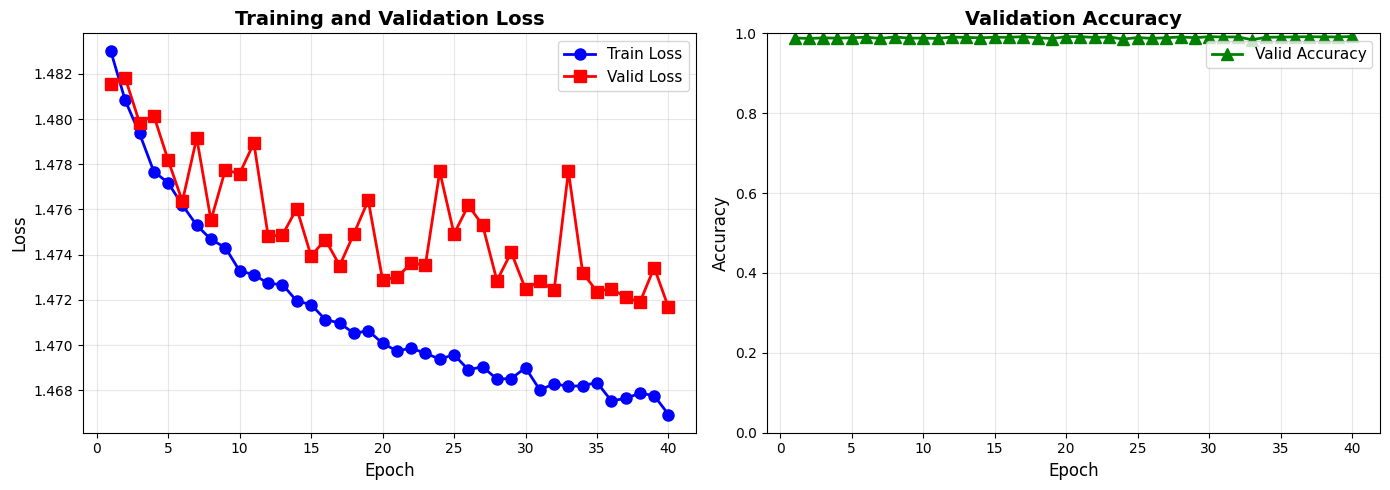


=== 学習結果サマリー ===
最終訓練損失: 1.4669
最終検証損失: 1.4717
最終検証精度: 0.9921
最良検証精度: 0.9921 (Epoch 40)


In [46]:
# 学習過程の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 損失の推移
epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=8)
ax1.plot(epochs, history['valid_loss'], 'r-s', label='Valid Loss', linewidth=2, markersize=8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 精度の推移
ax2.plot(epochs, history['valid_accuracy'], 'g-^', label='Valid Accuracy', linewidth=2, markersize=8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# 最終結果の表示
print("\n=== 学習結果サマリー ===")
print(f"最終訓練損失: {history['train_loss'][-1]:.4f}")
print(f"最終検証損失: {history['valid_loss'][-1]:.4f}")
print(f"最終検証精度: {history['valid_accuracy'][-1]:.4f}")
print(f"最良検証精度: {max(history['valid_accuracy']):.4f} (Epoch {history['valid_accuracy'].index(max(history['valid_accuracy'])) + 1})")

学習済みモデルの予測結果を確認

In [47]:
predict_df = predict_img(model, valid_loader)

100%|██████████| 235/235 [00:09<00:00, 24.69it/s]


混合行列でCapsNetのそれぞれの数字の精度を確認

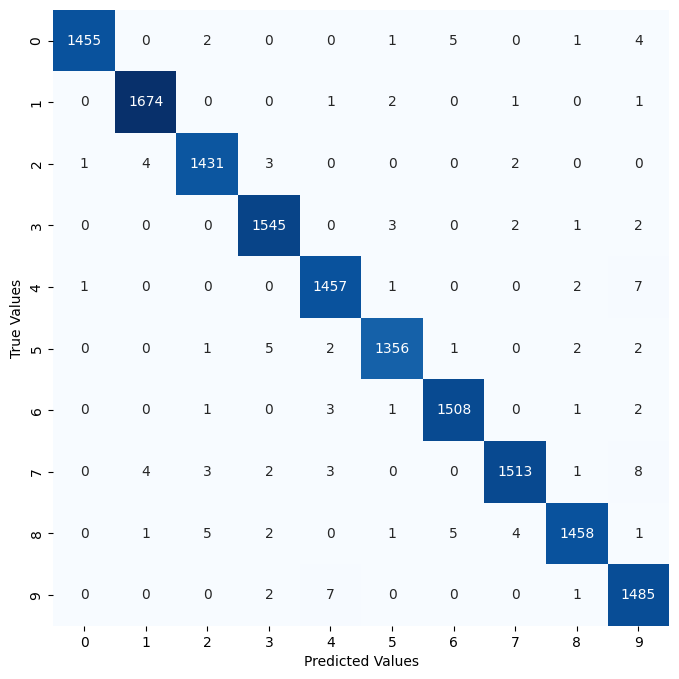

In [48]:
plt.figure(figsize=(8,8))
mat = confusion_matrix(predict_df["label"], predict_df["predict"]) # Confusion matrix
# Plot Confusion matrix
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap=plt.cm.Blues, fmt="d")
plt.xlabel('Predicted Values')
plt.ylabel('True Values');
plt.show();

間違えた予測の一覧を確認します

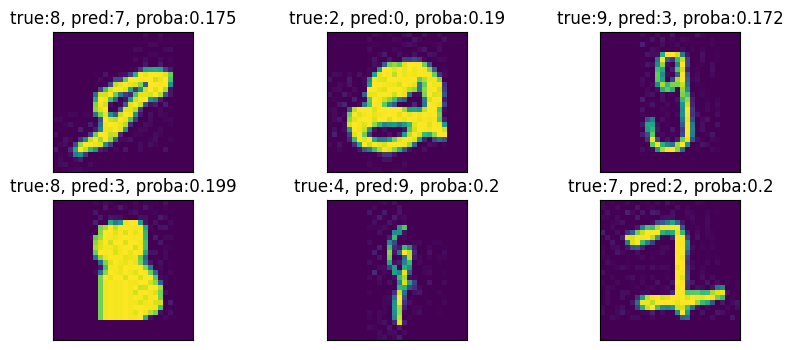

In [49]:
# 大きく間違えた予測
error_index = predict_df[predict_df["label"] != predict_df["predict"]].sort_values(by="loss",ascending=False).head(6).index
plt.figure(figsize=(10,4))
for i, ind in enumerate(error_index):
    label = int(predict_df.iloc[ind]["label"])
    pred = int(predict_df.iloc[ind]["predict"])
    proba = predict_df.iloc[ind]["proba_"+str(pred)]

    image_name = valid.reset_index(drop=True).loc[ind, "file_name"]
    image = cv2.imread(f"../data/train/{image_name}", cv2.IMREAD_GRAYSCALE)
    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title("true:{}, pred:{}, proba:{}".format(label, pred, proba.round(3)))
    plt.xticks(())
    plt.yticks(())
plt.show()

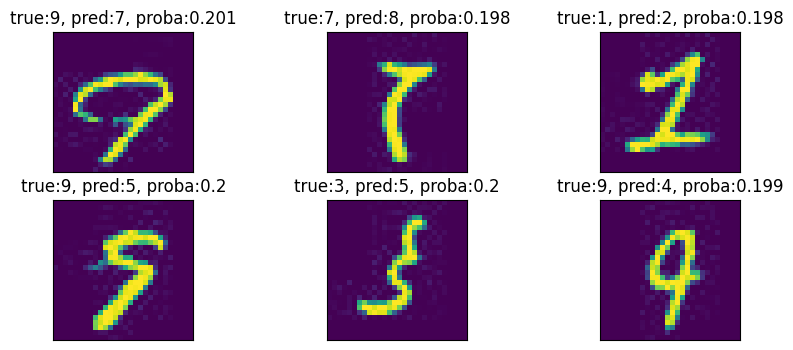

In [50]:
# 惜しい予測
error_index = predict_df[predict_df["label"] != predict_df["predict"]].sort_values(by="loss",ascending=False).tail(6).index
plt.figure(figsize=(10,4))
for i, ind in enumerate(error_index):
    label = int(predict_df.iloc[ind]["label"])
    pred = int(predict_df.iloc[ind]["predict"])
    proba = predict_df.iloc[ind]["proba_"+str(pred)]

    image_name = valid.reset_index(drop=True).loc[ind, "file_name"]
    image = cv2.imread(f"../data/train/{image_name}", cv2.IMREAD_GRAYSCALE)
    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title("true:{}, pred:{}, proba:{}".format(label, pred, proba.round(3)))
    plt.xticks(())
    plt.yticks(())
plt.show()

評価用画像データに対して予測値を出力する関数を実装します.

In [51]:
submit = pd.read_csv("../assets/sample_submit.csv", header=None)
submit.head()

,0,1
0,test_0.jpg,2
1,test_1.jpg,4
2,test_2.jpg,5
3,test_3.jpg,4
4,test_4.jpg,3


In [52]:
# DataSetの形式に合わせるため、ヘッダを少し変更
submit.columns = ["file_name", "category_id"]

In [53]:
test_data = MNIST_data(submit, mode="test", transform=transform_test)
test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=batch_size)

In [54]:
def model_predict(input_model, input_data):
    input_model.eval()
    test_pred = torch.LongTensor()
    for data, _ in tqdm.tqdm(input_data):
        data = data.to(device)
        output = model(data)
        pred = output.cpu().data.max(1, keepdim=True)[1]
        test_pred = torch.cat((test_pred, pred), dim=0)
    return test_pred

In [55]:
predict = model_predict(model, test_loader)

100%|██████████| 157/157 [00:02<00:00, 66.46it/s]


In [56]:
predict = predict.cpu().detach().numpy().reshape(-1).copy()

In [57]:
submit["category_id"] = predict

In [58]:
submit.head()

,file_name,category_id
0,test_0.jpg,7
1,test_1.jpg,2
2,test_2.jpg,1
3,test_3.jpg,0
4,test_4.jpg,4


In [59]:
submit.to_csv('../output/submission_capsnet.csv', index=False, header=None)

# まとめ

今回はLeNetの畳み込みステムを活用したCapsule Networkを実装しました.

## Capsule Networkの特徴

- **Primary Capsule Layer**: 畳み込み層の出力をカプセル表現（ベクトル）に変換
- **Digit Capsule Layer**: Dynamic Routingアルゴリズムを用いて各クラスのカプセルを生成
- **Squash関数**: カプセルの長さを0-1の範囲に正規化

Capsule Networkは通常のCNNと比較して、物体の部分-全体の関係性をより良く捉えることができます.

## 改善のヒント

- エポック数を増やす
- Dynamic Routingのイテレーション数を調整
- カプセルの次元数やカプセル数を変更
- データ拡張（回転、平行移動など）を追加
- 学習率のスケジューリング